# WIP

In [9]:
from macrohet import dataio, tile
from pathlib import Path

In [11]:
base_dir = '/mnt/OPERA2/Baptiste/20250808_ND_Test_zstack/20250808_ND-test_zstack__2025-08-08T16_38_15-Measurement 1'

In [12]:
metadata = dataio.read_harmony_metadata(Path(base_dir, 'Images/Index.idx.xml'))

Reading metadata XML file...


0it [00:00, ?it/s]

Extracting metadata complete!


In [8]:
metadata

,id,State,URL,Row,Col,FieldID,PlaneID,TimepointID,ChannelID,FlimID,...,PositionZ,AbsPositionZ,MeasurementTimeOffset,AbsTime,MainExcitationWavelength,MainEmissionWavelength,ObjectiveMagnification,ObjectiveNA,ExposureTime,OrientationMatrix
0,0303K1F1P1R1,Ok,r03c03f01p01-ch1sk1fk1fl1.tiff,3,3,1,1,0,1,1,...,-5E-06,0.135291502,0,2025-08-08T16:38:29.853+01:00,640,706,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
1,0303K1F1P1R2,Ok,r03c03f01p01-ch2sk1fk1fl1.tiff,3,3,1,1,0,2,1,...,-5E-06,0.135291502,0,2025-08-08T16:38:30.197+01:00,561,599,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
2,0303K1F1P2R1,Ok,r03c03f01p02-ch1sk1fk1fl1.tiff,3,3,1,2,0,1,1,...,-4E-06,0.1352925,0,2025-08-08T16:38:30.477+01:00,640,706,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
3,0303K1F1P2R2,Ok,r03c03f01p02-ch2sk1fk1fl1.tiff,3,3,1,2,0,2,1,...,-4E-06,0.1352925,0,2025-08-08T16:38:30.743+01:00,561,599,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
4,0303K1F1P3R1,Ok,r03c03f01p03-ch1sk1fk1fl1.tiff,3,3,1,3,0,1,1,...,-3E-06,0.135293499,0,2025-08-08T16:38:31.023+01:00,640,706,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232645,0404K97F16P23R2,Ok,r04c04f16p23-ch2sk97fk1fl1.tiff,4,4,16,23,96,2,1,...,1.7E-05,0.135240495,172803.576,2025-08-10T16:49:50.647+01:00,561,599,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
232646,0404K97F16P24R1,Ok,r04c04f16p24-ch1sk97fk1fl1.tiff,4,4,16,24,96,1,1,...,1.8E-05,0.135241494,172803.576,2025-08-10T16:49:50.91+01:00,640,706,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
232647,0404K97F16P24R2,Ok,r04c04f16p24-ch2sk97fk1fl1.tiff,4,4,16,24,96,2,1,...,1.8E-05,0.135241494,172803.576,2025-08-10T16:49:51.19+01:00,561,599,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."
232648,0404K97F16P25R1,Ok,r04c04f16p25-ch1sk97fk1fl1.tiff,4,4,16,25,96,1,1,...,1.9E-05,0.135242507,172803.576,2025-08-10T16:49:51.457+01:00,640,706,40,1.1,0.2,"[[0.988526,0,0,-9.8],[0,-0.988526,0,-9.9],[0,0..."


In [17]:
metadata[['Row', 'Col']].drop_duplicates()

,Row,Col
0,3,3
800,3,4
1600,4,4


In [26]:
metadata['ImageResolutionX'].unique()

array(['1.4949402023919043E-07'], dtype=object)

In [23]:
metadata['PositionZ'].unique()

array(['-5E-06', '-4E-06', '-3E-06', '-2E-06', '-1E-06', '0', '1E-06',
       '2E-06', '3E-06', '4E-06', '5E-06', '6E-06', '7E-06', '8E-06',
       '9E-06', '1E-05', '1.1E-05', '1.2E-05', '1.3E-05', '1.4E-05',
       '1.5E-05', '1.6E-05', '1.7E-05', '1.8E-05', '1.9E-05'],
      dtype=object)

In [19]:
image_dir

PosixPath('/mnt/OPERA2/Baptiste/20250808_ND_Test_zstack/20250808_ND-test_zstack__2025-08-08T16_38_15-Measurement 1/Images')

In [20]:
image_dir = Path(base_dir, 'Images')
images = tile.compile_mosaic(str(image_dir), metadata, row=3, col=3,  n_tile_cols=4, n_tile_rows=4)

In [21]:
images

dask.array<reshape, shape=(97, 2, 25, 7992, 7992), dtype=uint16, chunksize=(1, 1, 1, 2160, 2160), chunktype=numpy.ndarray>

In [24]:
import napari

In [27]:
viewer = napari.Viewer(title = 'deep Z stack')

viewer.add_image(images, channel_axis = 1, scale = (1.0, 0.14949402023919043, 0.14949402023919043))

[<Image layer 'Image' at 0x756ebff73460>,
 <Image layer 'Image [1]' at 0x756ea0380c40>]

In [30]:
viewer.scale_bar.visible = True
viewer.scale_bar.unit = "µm"       # units displayed on bar
viewer.scale_bar.position = "bottom_right"  # other options: top_left, bottom_left, top_right
viewer.scale_bar.colored = False    # use layer colormap for scalebar color

Traceback (most recent call last):
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/app/backends/_qt.py", line 963, in paintGL
    self._vispy_canvas.events.draw(region=None)
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/util/event.py", line 453, in __call__
    self._invoke_callback(cb, event)
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/util/event.py", line 471, in _invoke_callback
    _handle_exception(self.ignore_callback_errors,
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/util/event.py", line 469, in _invoke_callback
    cb(event)
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/scene/canvas.py", line 219, in on_draw
    self._draw_scene()
  File "/home/dayn/miniconda3/envs/macrohet/lib/python3.10/site-packages/vispy/scene/canvas.py", line 278, in _draw_scene
    self.draw_visual(self.scene)
  File "/home/dayn/miniconda3/

# Segment


In [1]:
import napari
import numpy as np
import zarr
from cellpose import core, models
from tqdm.auto import tqdm



Welcome to CellposeSAM, cellpose v4.0.1! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




In [2]:
import torch

if torch.cuda.is_available():
    print("GPU is available!")
    print("Device name:", torch.cuda.get_device_name(0))
else:
    print("No GPU available.")

GPU is available!
Device name: NVIDIA RTX A6000


In [3]:
zarr_dir = '/mnt/DATA2/VP0001/acquisition/zarr/pos_15.zarr/'
zarr_group = zarr.open_group(zarr_dir)

In [5]:
%%time
segmentation_input = zarr_group.images[0,-1,:,...]
segmentation_input.shape

CPU times: user 40.3 ms, sys: 88.2 ms, total: 128 ms
Wall time: 59.9 ms


(32, 1024, 1024)

In [6]:
viewer = napari.Viewer()
viewer.add_image(segmentation_input)

<Image layer 'segmentation_input' at 0x7fe5d0abebf0>

In [7]:
model = models.CellposeModel(gpu=True)

In [8]:
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

In [8]:
flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0
batch_size = 128
masks, flows, styles = model.eval(images[0:2], 
                                  channel_axis=1,
                                  z_axis=2, do_3D=True,
                                  progress=True,
                                  batch_size=batch_size, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

more than 3 channels provided, only segmenting on first 3 channels
no seeds found in get_masks_torch - no masks found.
more than 3 channels provided, only segmenting on first 3 channels

KeyboardInterrupt



In [9]:
import sys

# Get a dictionary of all variables in the current scope
all_vars = globals().copy()

# Remove built-in variables and some special ones
to_exclude = ['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__']
vars_to_check = {k: v for k, v in all_vars.items() if not k.startswith('_') and k not in to_exclude}

# Function to get the size of an object in bytes
def get_size(obj):
    return sys.getsizeof(obj)

# Get the size of each variable
var_sizes = [(k, get_size(v)) for k, v in vars_to_check.items()]

# Sort by size in descending order
sorted_vars = sorted(var_sizes, key=lambda item: item[1], reverse=True)

# Print the largest variables
print("Largest variables in memory:")
for name, size in sorted_vars[:10]:  # Display the top 10 largest
    print(f"{name}: {size / (1024 * 1024):.2f} MB")

Largest variables in memory:
segmentation_input: 32.00 MB
tqdm: 0.00 MB
Out: 0.00 MB
In: 0.00 MB
open: 0.00 MB
viewer: 0.00 MB
zarr_dir: 0.00 MB
zarr: 0.00 MB
models: 0.00 MB
core: 0.00 MB


In [122]:
del segmentation_input
del masks

NameError: name 'segmentation_input' is not defined

In [10]:
## !! this worked to clear the cache! 
import gc

gc.collect()
torch.cuda.empty_cache()

In [11]:
 # 'dims_n': {1: 1024, 2: 1024, 3: 27, 4: 289},
 # 'scale_n': {1: 3.52, 2: 3.52, 3: 2.499581800737184, 4: 0.0011109246712067999},
anisotropy = 2.499581800737184 / 3.52 

In [103]:
%%time
flow_threshold = 0.4
cellprob_threshold = 0
tile_norm_blocksize = 0
batch_size = 256
diameter = 100
masks, flows, styles = model.eval(segmentation_input[0], 
                                  diameter=diameter,
                                  anisotropy=1/anisotropy,
                                  min_size=2000,
                                  # channel_axis=1,
                                  z_axis=0, do_3D=True,
                                  # progress=True,
                                  # batch_size=batch_size, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  # normalize={"tile_norm_blocksize": tile_norm_blocksize}
                                 )

Resizing is depricated in v4.0.1+


CPU times: user 1min 49s, sys: 77 ms, total: 1min 49s
Wall time: 1min 47s


In [17]:
%%time
flow_threshold = 0.4
cellprob_threshold = 0
tile_norm_blocksize = 0
batch_size = 512
diameter = 100
masks, flows, styles = model.eval(segmentation_input, 
                                  diameter=diameter,
                                  anisotropy=1/anisotropy,
                                  min_size=2000,
                                  # channel_axis=1,
                                  z_axis=0, do_3D=True, flow3D_smooth = 2,
                                  # progress=True,
                                  # batch_size=batch_size, 
                                  flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  # normalize={"tile_norm_blocksize": tile_norm_blocksize}
                                 )

Resizing is depricated in v4.0.1+


CPU times: user 1min 49s, sys: 926 ms, total: 1min 50s
Wall time: 1min 47s


In [18]:
viewer.add_labels(masks, name = 'reverse anisotropy applied, diameter, 0,0 flow and cellprob')

<Labels layer 'reverse anisotropy applied, diameter, 0,0 flow and cellprob [1]' at 0x7fe58ff43190>

In [108]:
masks.shape

(32, 1024, 1024)

In [110]:
for layer in viewer.layers:
    layer.scale = (anisotropy, 1, 1)

In [16]:
help(model.eval)

Help on method eval in module cellpose.models:

eval(x, batch_size=8, resample=None, channels=None, channel_axis=None, z_axis=None, normalize=True, invert=False, rescale=None, diameter=None, flow_threshold=0.4, cellprob_threshold=0.0, do_3D=False, anisotropy=None, flow3D_smooth=0, stitch_threshold=0.0, min_size=15, max_size_fraction=0.4, niter=None, augment=False, tile_overlap=0.1, bsize=256, compute_masks=True, progress=None) method of cellpose.models.CellposeModel instance
    segment list of images x, or 4D array - Z x 3 x Y x X
    
    Args:
        x (list, np.ndarry): can be list of 2D/3D/4D images, or array of 2D/3D/4D images. Images must have 3 channels.
        batch_size (int, optional): number of 256x256 patches to run simultaneously on the GPU
            (can make smaller or bigger depending on GPU memory usage). Defaults to 64.
        resample (bool, optional): run dynamics at original image size (will be slower but create more accurate boundaries). 
            depreca

In [19]:
%%time
segmentation_input = zarr_group.images[:,-1,:,...]
segmentation_input.shape

CPU times: user 4.56 s, sys: 28.7 s, total: 33.3 s
Wall time: 10.1 s


(289, 32, 1024, 1024)

In [23]:
%%time
flow_threshold = 0.4
cellprob_threshold = 0
tile_norm_blocksize = 0
batch_size = 64
diameter = 100
masks_stack = []
for i, segmentation_input_frame in tqdm(enumerate(segmentation_input), total = len(segmentation_input)):
    masks, flows, styles = model.eval(segmentation_input_frame, 
                                      diameter=diameter,
                                      anisotropy=1/anisotropy,
                                      min_size=2000,
                                      # channel_axis=1,
                                      z_axis=0, do_3D=True,
                                      # progress=True,
                                      # batch_size=batch_size, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                      # normalize={"tile_norm_blocksize": tile_norm_blocksize}
                                     )
    masks_stack.append(masks)
    np.save(f'temp_frame_{i}.npy', masks)
masks_stack = np.stack(masks, axis=0)

  0%|          | 0/289 [00:00<?, ?it/s]

Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is depricated in v4.0.1+
Resizing is de

CPU times: user 8h 52min 5s, sys: 4min 27s, total: 8h 56min 32s
Wall time: 8h 43min 21s


In [22]:
help(np.save)

Help on _ArrayFunctionDispatcher in module numpy:

save(file, arr, allow_pickle=True, fix_imports=True)
    Save an array to a binary file in NumPy ``.npy`` format.
    
    Parameters
    ----------
    file : file, str, or pathlib.Path
        File or filename to which the data is saved.  If file is a file-object,
        then the filename is unchanged.  If file is a string or Path, a ``.npy``
        extension will be appended to the filename if it does not already
        have one.
    arr : array_like
        Array data to be saved.
    allow_pickle : bool, optional
        Allow saving object arrays using Python pickles. Reasons for disallowing
        pickles include security (loading pickled data can execute arbitrary
        code) and portability (pickled objects may not be loadable on different
        Python installations, for example if the stored objects require libraries
        that are not available, and not all pickled data is compatible between
        Python 2 and Py

In [97]:
segmentation_input_frame.shape

(32, 1024, 1024)

# Trackastra

In [5]:
zarr_dir = '/mnt/DATA2/VP0001/acquisition/zarr/pos_15.zarr/'
zarr_group = zarr.open_group(zarr_dir)

In [11]:
masks = [np.load(fn) for fn in natsorted(glob.glob('/mnt/DATA2/VP0001/labels/pos_15/dev/btrack/*.npy'))]
segmentation = np.stack(masks, axis = 0)

In [12]:
segmentation.shape

(289, 32, 1024, 1024)

In [13]:
%%time
images = zarr_group.images[...]
images.shape

CPU times: user 48.3 s, sys: 54.4 s, total: 1min 42s
Wall time: 5min 33s


(289, 3, 32, 1024, 1024)

In [8]:
import torch
from trackastra.model import Trackastra
from trackastra.tracking import graph_to_ctc, graph_to_napari_tracks

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load a pretrained model
model = Trackastra.from_pretrained("ctc", device=device)

# or from a local folder
# model = Trackastra.from_folder('path/my_model_folder/', device=device)


/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/tmp/tmp18nobcv5/ctc.zip: 100%|██████████████████████████████████████████████████| 82.2M/82.2M [00:02<00:00, 33.8MiB/s]
INFO:trackastra.model.model:Loading model state from /home/dayn/.trackastra/.models/ctc/model.pt
/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/trackastra/model/model.py:498: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weigh

In [11]:
images[:,-1,...].shape, segmentation.shape

((289, 32, 1024, 1024), (289, 32, 1024, 1024))

In [25]:
%%time
# Track the cells
track_graph = model.track(images[:,-1,...], segmentation, mode="greedy_nodiv")  # or mode="ilp", or "greedy_nodiv"


# Write to cell tracking challenge format
ctc_tracks, masks_tracked = graph_to_ctc(
      track_graph,
      segmentation,
      outdir="/mnt/DATA2/VP0001/labels/pos_15/dev/trackastra",
)

INFO:trackastra.model.model_api:Predicting weights for candidate graph
INFO:trackastra.data.wrfeat:Extracting features from 289 detections
INFO:trackastra.data.wrfeat:Using single process for feature extraction
Extracting features: 100%|███████████████████████████████████████████████████████████| 289/289 [11:08<00:00,  2.31s/it]
INFO:trackastra.model.model_api:Building windows
Building windows: 100%|███████████████████████████████████████████████████████████| 286/286 [00:00<00:00, 13337.16it/s]
INFO:trackastra.model.model_api:Predicting windows
Computing associations: 100%|████████████████████████████████████████████████████████| 286/286 [00:14<00:00, 19.97it/s]
INFO:trackastra.model.model_api:Running greedy tracker
INFO:trackastra.tracking.tracking:Build candidate graph with delta_t=1
INFO:trackastra.tracking.tracking:Added 25091 vertices, 25934 edges                                                    
INFO:trackastra.tracking.tracking:Running greedy tracker
Saving masks: 100%|███████

CPU times: user 16min 23s, sys: 39.9 s, total: 17min 3s
Wall time: 16min 1s


In [26]:
napari_tracks, napari_tracks_graph, _ = graph_to_napari_tracks(track_graph)

100%|█████████████████████████████████████████████████████████████████████████████| 744/744 [00:00<00:00, 15425.95it/s]


In [28]:
# viewer = napari.Viewer(title = 'trackastra tests')

# viewer.add_image(images, channel_axis=1)
# viewer.add_labels(segmentation, opacity=0.1)
viewer.add_labels(masks_tracked, opacity=0.7)
viewer.add_tracks(data=napari_tracks, graph=napari_tracks_graph)

<Tracks layer 'napari_tracks [3]' at 0x7f9c94ba2860>

INFO:OpenGL.acceleratesupport:No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'


In [31]:
napari_tracks

array([[1.00000000e+00, 0.00000000e+00, 1.67971649e+01, 2.74576416e+02,
        5.74737427e+02],
       [1.00000000e+00, 1.00000000e+00, 1.60987740e+01, 2.70456635e+02,
        5.76396912e+02],
       [1.00000000e+00, 2.00000000e+00, 1.57913742e+01, 2.73498688e+02,
        5.73241516e+02],
       ...,
       [7.44000000e+02, 1.11000000e+02, 1.45530872e+01, 1.00019012e+03,
        8.48523010e+02],
       [7.44000000e+02, 1.12000000e+02, 1.50798454e+01, 1.00185834e+03,
        8.47549927e+02],
       [7.44000000e+02, 1.13000000e+02, 1.54014273e+01, 1.00411450e+03,
        8.38077820e+02]])

In [33]:
import pandas as pd

In [40]:
tracks = pd.DataFrame(napari_tracks, columns=['ID', 't', 'z', 'y', 'x'])

In [45]:
tracks

,ID,t,z,y,x
0,1.0,0.0,16.797165,274.576416,574.737427
1,1.0,1.0,16.098774,270.456635,576.396912
2,1.0,2.0,15.791374,273.498688,573.241516
3,1.0,3.0,15.765885,277.548981,574.386230
4,1.0,4.0,15.915837,279.359253,569.098145
...,...,...,...,...,...
24634,744.0,109.0,14.591660,1000.552002,840.215210
24635,744.0,110.0,15.352196,1000.230713,843.508484
24636,744.0,111.0,14.553087,1000.190125,848.523010
24637,744.0,112.0,15.079845,1001.858337,847.549927


### Compare to btrack

In [64]:
file_path = '/mnt/DATA2/VP0001/labels/pos_15/dev/btrack/tracks.csv'
#column_names = ['ID', 't', 'x', 'y', 'z', 'parent', 'root', 'state', 'generation', 'dummy', 'mean_intensity-0', 'mean_intensity-1', 'area', 'mean_intensity-2', 'mean_intensity-3']
btracks = pd.read_csv(file_path, delimiter=' ',
                      # names=column_names, 
                      header=0)
btracks

,ID,t,x,y,z,parent,root,state,generation,dummy,mean_intensity-0,mean_intensity-1,area,mean_intensity-2,mean_intensity-3
0,81,0,504.926056,761.627075,15.785276,81,81,5,0,0,0.509174,0.000239,171411.0,0.0,1.109917
1,96,0,784.564331,67.316917,19.108788,96,96,5,0,0,0.813253,0.000618,119729.0,0.0,1.607572
2,96,1,780.897522,72.921066,18.624977,96,96,5,0,0,0.715703,0.000521,101679.0,0.0,1.472595
3,96,2,783.530334,67.522774,20.894230,96,96,5,0,0,0.739013,0.000534,104898.0,0.0,1.554243
4,96,3,789.720520,62.943974,20.163734,96,96,5,0,0,0.798508,0.000566,79482.0,0.0,1.669623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32512,9689,288,776.250000,999.535706,13.500000,9689,9689,5,0,0,0.273810,0.000000,168.0,0.0,0.589286
32513,9688,288,355.000000,342.000000,16.000000,9688,9688,5,0,0,0.222222,0.000000,27.0,0.0,0.518519
32514,9687,288,163.500000,762.000000,23.500000,9687,9687,5,0,0,0.527778,0.000000,36.0,0.0,0.888889
32515,9686,288,879.000000,602.000000,26.000000,9686,9686,5,0,0,0.444444,0.000000,27.0,0.0,0.407407


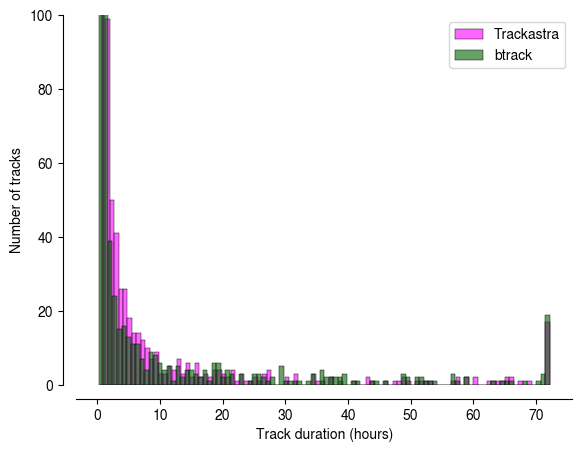

In [82]:
sns.histplot(tracks.groupby('ID').size() * 0.25, color='magenta', bins=100, label='Trackastra', alpha = 0.6)
sns.histplot(btracks.groupby('ID').size() * 0.25, color='darkgreen', bins=100, label='btrack', alpha = 0.6)
plt.legend()
plt.xlabel('Track duration (hours)')
plt.ylabel('Number of tracks')
plt.ylim(0,100)
sns.despine(offset=10)
plt.savefig('/mnt/DATA2/VP0001/labels/pos_15/dev/btrackastra_length_comparison.pdf', bbox_inches ='tight', dpi = 314)

In [84]:
pd.DataFrame.to_csv

<function pandas.core.generic.NDFrame.to_csv(self, path_or_buf: 'FilePath | WriteBuffer[bytes] | WriteBuffer[str] | None' = None, *, sep: 'str' = ',', na_rep: 'str' = '', float_format: 'str | Callable | None' = None, columns: 'Sequence[Hashable] | None' = None, header: 'bool_t | list[str]' = True, index: 'bool_t' = True, index_label: 'IndexLabel | None' = None, mode: 'str' = 'w', encoding: 'str | None' = None, compression: 'CompressionOptions' = 'infer', quoting: 'int | None' = None, quotechar: 'str' = '"', lineterminator: 'str | None' = None, chunksize: 'int | None' = None, date_format: 'str | None' = None, doublequote: 'bool_t' = True, escapechar: 'str | None' = None, decimal: 'str' = '.', errors: 'OpenFileErrors' = 'strict', storage_options: 'StorageOptions | None' = None) -> 'str | None'>

In [87]:
tracks.to_csv('/mnt/DATA2/VP0001/labels/pos_15/dev/trackastra/tracks.csv', index=False)

In [14]:
import pandas as pd

In [15]:
tracks = pd.read_csv('/mnt/DATA2/VP0001/labels/pos_15/dev/trackastra/tracks.csv')

In [32]:
tracks

,ID,t,z,y,x
0,1.0,0.0,16.797165,274.576416,574.737427
1,1.0,1.0,16.098774,270.456635,576.396912
2,1.0,2.0,15.791374,273.498688,573.241516
3,1.0,3.0,15.765885,277.548981,574.386230
4,1.0,4.0,15.915837,279.359253,569.098145
...,...,...,...,...,...
24634,744.0,109.0,14.591660,1000.552002,840.215210
24635,744.0,110.0,15.352196,1000.230713,843.508484
24636,744.0,111.0,14.553087,1000.190125,848.523010
24637,744.0,112.0,15.079845,1001.858337,847.549927


## Now measure the expression of fluorescence markers across ALL DIMENSIONS

In [16]:
images.shape, segmentation.shape

((289, 3, 32, 1024, 1024), (289, 32, 1024, 1024))

In [122]:
masks_tracked.shape

(289, 32, 1024, 1024)

In [97]:
tracks.round()

,ID,t,z,y,x
0,1.0,0.0,17.0,275.0,575.0
1,1.0,1.0,16.0,270.0,576.0
2,1.0,2.0,16.0,273.0,573.0
3,1.0,3.0,16.0,278.0,574.0
4,1.0,4.0,16.0,279.0,569.0
...,...,...,...,...,...
24634,744.0,109.0,15.0,1001.0,840.0
24635,744.0,110.0,15.0,1000.0,844.0
24636,744.0,111.0,15.0,1000.0,849.0
24637,744.0,112.0,15.0,1002.0,848.0


In [114]:
for i, row in tracks.round().astype(int).iterrows():
    break

In [117]:
row

ID      1
t       0
z      17
y     275
x     575
Name: 0, dtype: int64

In [121]:
segmentation_ID = segmentation[row['t'], row['z'], row['y'], row['x']]

20

In [118]:
images[row['t'], :, row['z'], row['y'], row['x']]


array([  0,   0, 131], dtype=uint8)

# Otsu segmentation for mtb quantification

In [17]:
images.shape

(289, 3, 32, 1024, 1024)

In [18]:
mtb_channel = np.max(images[:,0:2,...], axis = 1)

In [19]:
mtb_channel.shape

(289, 32, 1024, 1024)

In [129]:
viewer.add_image(mtb_channel, name = 'mtb')

<Image layer 'mtb' at 0x7f9c93bfc100>

In [52]:
from skimage.filters import median, threshold_multiotsu


In [132]:
img = mtb_channel[0,15,...]

In [143]:
thresholds = threshold_multiotsu(img)

In [144]:
thresholds

array([ 6, 42])

In [141]:
regions = np.digitize(img, bins=thresholds)

In [142]:
viewer.add_image(regions)

<Image layer 'regions [1]' at 0x7f9c2cd8e980>

In [160]:
thresholded = (img >= 42).astype(np.uint8)

In [161]:
viewer.add_image(thresholded)

<Image layer 'thresholded [4]' at 0x7f9c2c878f10>

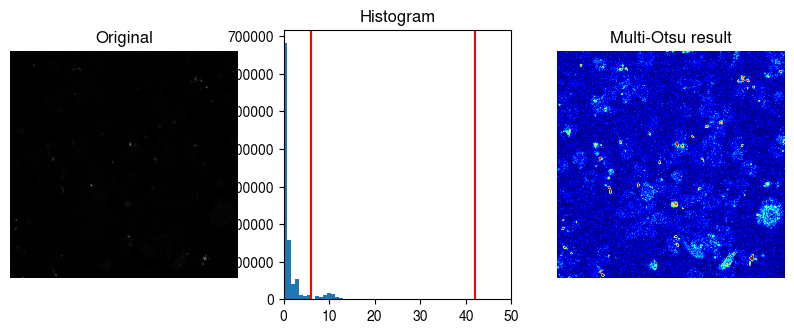

In [157]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3.5))

# Plotting the original image.
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Plotting the histogram and the two thresholds obtained from
# multi-Otsu.
ax[1].hist(img.ravel(), bins=255)
ax[1].set_title('Histogram')
for thresh in thresholds:
    ax[1].axvline(thresh, color='r')
ax[1].set_xlim(0,50)

# Plotting the Multi Otsu result.
ax[2].imshow(regions, cmap='jet')
ax[2].set_title('Multi-Otsu result')
ax[2].axis('off')

plt.subplots_adjust()

plt.show()

In [165]:
mtb_channel.shape

(289, 32, 1024, 1024)

In [166]:
mtb_channel[0].shape

(32, 1024, 1024)

In [168]:
thresholds = threshold_multiotsu(mtb_channel[0])
thresholds

array([ 6, 58])

In [169]:
regions  = np.digitize(mtb_channel[0], bins=thresholds)
regions.shape

(32, 1024, 1024)

In [170]:
viewer.add_image(regions)

<Image layer 'regions [1]' at 0x7f9c2e488dc0>

### Iterate over frames applying otsu segmentation

In [29]:
threshold_values

array([ 6, 58])

In [ ]:
thresholded_mtb = np.empty_like(mtb_channel)
for i, mtb_frame in tqdm(enumerate(mtb_channel), total = len(mtb_channel)):
    threshold_values = threshold_multiotsu(mtb_frame)
    thresholded_mtb_frame = median((mtb_frame > threshold_values[-1]).astype(np.uint8))
    thresholded_mtb[i] = thresholded_mtb_frame

  0%|          | 0/289 [00:00<?, ?it/s]

In [58]:
# viewer = napari.Viewer(title = 'testing mtb thresholding')
viewer.add_image(thresholded_mtb)

<Image layer 'thresholded_mtb [2]' at 0x7f11241ff850>

In [55]:
test = median(thresholded_mtb_frame)

In [56]:
viewer.add_image(test)

<Image layer 'test' at 0x7f13bad73760>

In [40]:
tracks

,ID,t,z,y,x
0,1.0,0.0,16.797165,274.576416,574.737427
1,1.0,1.0,16.098774,270.456635,576.396912
2,1.0,2.0,15.791374,273.498688,573.241516
3,1.0,3.0,15.765885,277.548981,574.386230
4,1.0,4.0,15.915837,279.359253,569.098145
...,...,...,...,...,...
24634,744.0,109.0,14.591660,1000.552002,840.215210
24635,744.0,110.0,15.352196,1000.230713,843.508484
24636,744.0,111.0,14.553087,1000.190125,848.523010
24637,744.0,112.0,15.079845,1001.858337,847.549927


In [83]:
x_scale, y_scale, z_scale = 1/3.52, 1/3.52, 1/2.499581800737184
voxel_volume_um3 = x_scale * y_scale * z_scale

In [84]:
voxel_volume_um3

0.032288459055149404

In [86]:
tracks

,ID,t,z,y,x,mtb_volume
0,1.0,0.0,16.797165,274.576416,574.737427,None
1,1.0,1.0,16.098774,270.456635,576.396912,None
2,1.0,2.0,15.791374,273.498688,573.241516,None
3,1.0,3.0,15.765885,277.548981,574.386230,None
4,1.0,4.0,15.915837,279.359253,569.098145,None
...,...,...,...,...,...,...
24634,744.0,109.0,14.591660,1000.552002,840.215210,None
24635,744.0,110.0,15.352196,1000.230713,843.508484,None
24636,744.0,111.0,14.553087,1000.190125,848.523010,None
24637,744.0,112.0,15.079845,1001.858337,847.549927,None


In [94]:
track_timepoint

ID      1
t       0
z      17
y     275
x     575
Name: 0, dtype: int64

In [151]:
voxel_volume_um3

0.032288459055149404

In [159]:
# tracks['mtb_volume'] = np.zeros(len(tracks), dtype=int)
# tracks['cell_volume'] = np.zeros(len(tracks), dtype=int)
# tracks['green'] = np.zeros(len(tracks), dtype=int)
# tracks['red'] = np.zeros(len(tracks), dtype=int)

for i, track_timepoint in tqdm(tracks.round().astype(int).iterrows(), total = len(tracks)):
    t, z, y, x = track_timepoint['t'], track_timepoint['z'], track_timepoint['y'], track_timepoint['x'] 
    segment_ID = segmentation[t, z, y, x]
    segment = (segmentation[t] == segment_ID).astype(bool) 
    sc_mtb_load = segment * thresholded_mtb[t]
    n_voxels = np.count_nonzero(sc_mtb_load)
    tracks.loc[i, 'mtb_volume'] = n_voxels * voxel_volume_um3
    tracks.loc[i, 'cell_volume'] = np.count_nonzero(segment)
    green_frame = images[t, 0, ...]
    green = np.mean(sc_mtb_load * green_frame)
    red_frame = images[t, 1, ...]
    red = np.mean(sc_mtb_load * red_frame)
    tracks.loc[i, 'green'] = green
    tracks.loc[i, 'red'] = red


  0%|          | 0/24639 [00:00<?, ?it/s]

In [152]:
viewer.add_labels(thresholded_mtb)


<Labels layer 'thresholded_mtb' at 0x7f1154740040>

In [141]:
segmentation.shape

(289, 32, 1024, 1024)

In [131]:
viewer.add_labels(segmentation)
viewer.add_image(images, channel_axis=1)

[<Image layer 'Image' at 0x7f13b118da50>,
 <Image layer 'Image [1]' at 0x7f13b0db7310>,
 <Image layer 'Image [2]' at 0x7f13b0c26b30>]

In [169]:
tracks

,ID,t,z,y,x,mtb_volume,green,red,cell_volume
0,1.0,0.0,16.797165,274.576416,574.737427,0.000000,0.000000,0.00000,164415
1,1.0,1.0,16.098774,270.456635,576.396912,0.000000,0.000000,0.00000,154747
2,1.0,2.0,15.791374,273.498688,573.241516,0.000000,0.000000,0.00000,156093
3,1.0,3.0,15.765885,277.548981,574.386230,0.096865,0.000004,0.00001,147842
4,1.0,4.0,15.915837,279.359253,569.098145,0.000000,0.000000,0.00000,151361
...,...,...,...,...,...,...,...,...,...
24634,744.0,109.0,14.591660,1000.552002,840.215210,0.000000,0.000000,0.00000,115154
24635,744.0,110.0,15.352196,1000.230713,843.508484,0.000000,0.000000,0.00000,133582
24636,744.0,111.0,14.553087,1000.190125,848.523010,0.000000,0.000000,0.00000,87724
24637,744.0,112.0,15.079845,1001.858337,847.549927,0.000000,0.000000,0.00000,78477


In [171]:
tracks.iloc[:, :5].values

array([[1.00000000e+00, 0.00000000e+00, 1.67971649e+01, 2.74576416e+02,
        5.74737427e+02],
       [1.00000000e+00, 1.00000000e+00, 1.60987740e+01, 2.70456635e+02,
        5.76396912e+02],
       [1.00000000e+00, 2.00000000e+00, 1.57913742e+01, 2.73498688e+02,
        5.73241516e+02],
       ...,
       [7.44000000e+02, 1.11000000e+02, 1.45530872e+01, 1.00019012e+03,
        8.48523010e+02],
       [7.44000000e+02, 1.12000000e+02, 1.50798454e+01, 1.00185834e+03,
        8.47549927e+02],
       [7.44000000e+02, 1.13000000e+02, 1.54014273e+01, 1.00411450e+03,
        8.38077820e+02]])

In [172]:
viewer.add_tracks(tracks.iloc[:, :5].values)

<Tracks layer 'Tracks' at 0x7f13b42abfd0>

Rendering frames...


100%|██████████████████████████████████████████████████████████████████████████████████| 46/46 [00:11<00:00,  3.97it/s]


Rendering frames...


100%|████████████████████████████████████████████████████████████████████████████████| 219/219 [00:45<00:00,  4.84it/s]


Rendering frames...


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:50<00:00,  5.24it/s]
Traceback (most recent call last):
  File "/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/napari_animation/_qt/frame_widget.py", line 66, in _update_animation_ease
    active_keyframe.ease = self.get_easing_func()
AttributeError: 'NoneType' object has no attribute 'ease'
Traceback (most recent call last):
  File "/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/napari_animation/_qt/frame_widget.py", line 66, in _update_animation_ease
    active_keyframe.ease = self.get_easing_func()
AttributeError: 'NoneType' object has no attribute 'ease'


Rendering frames...


100%|████████████████████████████████████████████████████████████████████████████████| 219/219 [00:43<00:00,  5.03it/s]


In [130]:
images.shape

(289, 3, 32, 1024, 1024)

In [166]:
tracks.to_csv('/mnt/DATA2/VP0001/labels/pos_15/dev/tracks_gr.csv')

In [121]:
tracks[tracks['mtb_volume'] > 130]

,ID,t,z,y,x,mtb_volume,green,red,cell_volume
9008,152.0,0.0,18.285177,510.067902,214.660126,131.220298,0.004401,0.014444,643280


In [164]:
filtered_tracks = tracks.groupby('ID').filter(lambda x: len(x) > 240)

In [162]:
tracks[(tracks['t'] ==20) & (tracks['mtb_volume'] >0)]

,ID,t,z,y,x,mtb_volume,green,red,cell_volume
20,1.0,20.0,15.718966,273.714508,568.061768,0.387462,1.579523e-05,0.000040,157618
140,2.0,20.0,16.171858,127.440353,95.342430,2.324769,5.581975e-05,0.000182,309431
278,3.0,20.0,15.624242,581.387268,417.060608,0.032288,8.940697e-07,0.000002,172100
527,7.0,20.0,15.494893,490.909180,731.783813,0.774923,2.601743e-05,0.000074,177224
1725,13.0,20.0,16.135134,919.358704,196.828644,3.293423,7.614493e-05,0.000236,162728
2590,29.0,20.0,17.690561,1005.056396,226.229141,5.489038,1.366735e-04,0.000400,76810
2887,42.0,20.0,16.035601,599.993225,127.943672,18.727306,6.115139e-04,0.001761,218981
3193,47.0,20.0,18.989832,348.955109,897.325684,5.166153,1.578331e-04,0.000582,139065
3400,49.0,20.0,15.842138,350.836426,556.971313,0.064577,6.258488e-07,0.000006,143866
3996,73.0,20.0,15.693705,90.531464,286.714050,1.937308,3.889203e-05,0.000148,412135


In [127]:
segmentation.shape

(289, 32, 1024, 1024)

In [124]:
import seaborn as sns

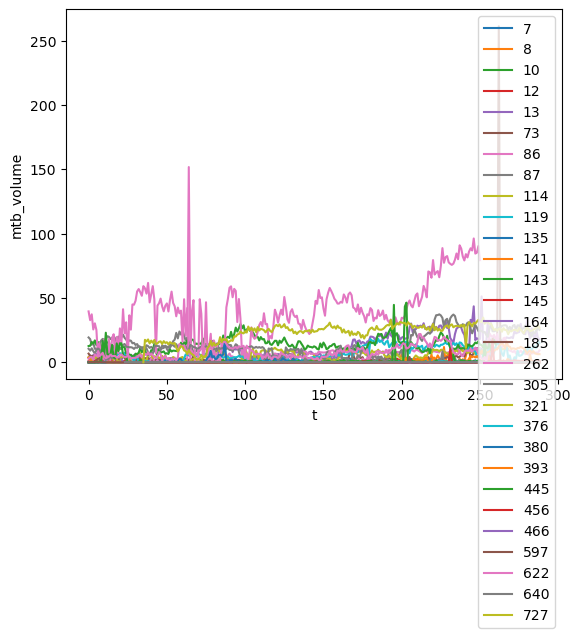

In [165]:
for ID, sc_df in filtered_tracks.groupby('ID'):
    x = sc_df['t']
    y = sc_df['mtb_volume']
    sns.lineplot(x=x, y=y, label=int(ID))
    

In [77]:
sc_mtb_load.shape

(32, 1024, 1024)

In [75]:
viewer.add_labels(sc_mtb_load)

<Labels layer 'sc_mtb_load' at 0x7f13c8f504f0>

In [ ]:
 # 'dims_n': {1: 1024, 2: 1024, 3: 27, 4: 289},
 # 'scale_n': {1: 3.52, 2: 3.52, 3: 2.499581800737184, 4: 0.0011109246712067999},
anisotropy = 2.499581800737184 / 3.52 